In [2]:
import cns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cns.data_utils as cdu

In [3]:
samples_df, cns_df = cdu.main_load("imp")

In [4]:
dict_input = cns.cns_df_to_segments(cns_df)
dict_breaks = cns.segments_to_breaks(dict_input)
dict_segs = cns.breaks_to_segments(dict_breaks)

# Step 1: Convert the dictionary to a DataFrame
df = pd.DataFrame.from_dict(dict_breaks, orient='index').transpose()

# Step 2: Calculate the breakpoints per chromosome
breakpoints_per_chr = pd.DataFrame({
    'Chromosome': list(dict_breaks.keys()),
    'Breakpoints': [len(value) - 2 for value in dict_breaks.values()]
}).set_index('Chromosome')

# Step 3: Calculate the total breakpoints
total_breakpoints = breakpoints_per_chr['Breakpoints'].sum()

# Step 4: Display the DataFrame and the total breakpoints
print("Breakpoints per chromosome:")
print(breakpoints_per_chr)
print("\nTotal breakpoints:", total_breakpoints)

Breakpoints per chromosome:
            Breakpoints
Chromosome             
chr1              65373
chr10             34272
chr11             46632
chr12             48111
chr13             23512
chr14             24549
chr15             19508
chr16             24408
chr17             33672
chr18             22934
chr19             27110
chr2              54436
chr20             23596
chr21             12173
chr22             13208
chr3              54309
chr4              42061
chr5              45516
chr6              50925
chr7              44282
chr8              52679
chr9              33859
chrX              29312
chrY                188

Total breakpoints: 826625


In [5]:
dict_fragile = cns.cns_df_to_segments(cns.fragile_sites_to_df(cns.hg19.fragile_sites))

fragile_per_chr = pd.DataFrame({
    'Chromosome': list(dict_fragile.keys()),
    'FragileSites': [len(value) for value in dict_fragile.values()]
}).set_index('Chromosome').sort_index()

print("Fragile sites per chromosome:")
print(fragile_per_chr)
print("\nTotal fragile sites:", fragile_per_chr['FragileSites'].sum())

Fragile sites per chromosome:
            FragileSites
Chromosome              
chr1                  11
chr10                  6
chr11                  9
chr12                  5
chr13                  5
chr14                  2
chr15                  1
chr16                  5
chr17                  2
chr18                  3
chr19                  2
chr2                  13
chr20                  2
chr22                  2
chr3                   4
chr4                   5
chr5                   8
chr6                   8
chr7                  11
chr8                   5
chr9                   5
chrX                   6

Total fragile sites: 120


In [6]:
# Shared setup for the fragile-site / breakpoint comparison.
assembly = cns.hg19
chroms = list(dict_breaks.keys())

# True if a position falls inside any fragile site on that chromosome.
def in_fragile(chrom, pos):
    return any(start <= pos < end for (start, end, _) in dict_fragile.get(chrom, []))

# Interior breakpoints, excluding the two chromosome-boundary breaks.
interior_breaks = {c: dict_breaks[c][1:-1] for c in chroms}

In [7]:
# Per-chromosome breakdown of the same two proportions.
rows = []
for c in chroms:
    chr_len = assembly.chr_lens[c]
    f_bp = sum(end - start for (start, end, _) in dict_fragile.get(c, []))
    p_genome = f_bp / chr_len

    breaks = interior_breaks[c]
    n_breaks = len(breaks)
    n_in = sum(in_fragile(c, p) for p in breaks)
    p_breaks = n_in / n_breaks if n_breaks else np.nan

    rows.append({
        'Chromosome': c,
        'FragileBp': f_bp,
        'ChrLen': chr_len,
        'GenomeFragile%': 100 * p_genome,
        'Breaks': n_breaks,
        'BreaksInFragile': n_in,
        'BreaksFragile%': 100 * p_breaks,
        'Enrichment': (p_breaks / p_genome) if p_genome else np.nan,
    })

per_chr = pd.DataFrame(rows).set_index('Chromosome')
per_chr = per_chr.reindex(sorted(per_chr.index))
per_chr['BreaksPerKb'] = per_chr['Breaks'] / per_chr['ChrLen'] * 1000
per_chr

,FragileBp,ChrLen,GenomeFragile%,Breaks,BreaksInFragile,BreaksFragile%,Enrichment,BreaksPerKb
Chromosome,,,,,,,,
chr1,114468504,249250621,45.925063,65373,29409,44.986462,0.979562,0.262278
chr10,48652656,135534747,35.896814,34272,12197,35.588819,0.991420,0.252865
chr11,47207588,135006516,34.966896,46632,15410,33.045977,0.945065,0.345406
chr12,53603672,133851895,40.047003,48111,13907,28.906071,0.721804,0.359435
chr13,34800096,115169878,30.216317,23512,7176,30.520585,1.010070,0.204151
chr14,12099999,107349540,11.271589,24549,3135,12.770378,1.132970,0.228683
chr15,8400139,102531392,8.192748,19508,2122,10.877589,1.327709,0.190264
chr16,12517171,90354753,13.853362,24408,3363,13.778269,0.994579,0.270135
chr17,5999997,81195210,7.389595,33672,2144,6.367308,0.861659,0.414704


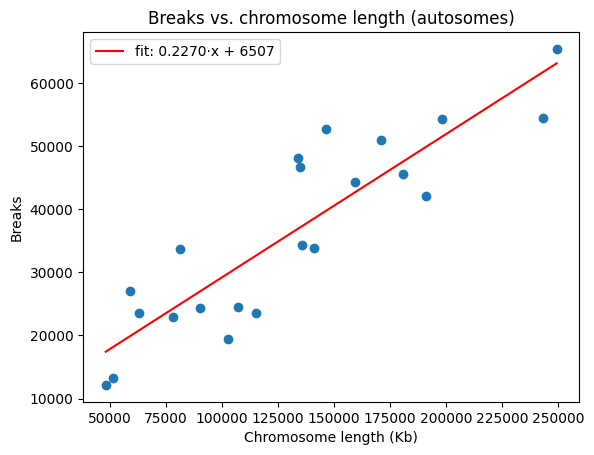

BreaksPerKb (autosomes): mean=0.2868, std=0.0702


In [8]:
aut = cns.only_aut(per_chr.reset_index().rename(columns={'Chromosome': 'chrom'}))

x = aut['ChrLen'] / 1000  # chromosome length in Kb
y = aut['Breaks']

fig, ax = plt.subplots()
ax.scatter(x, y)

# Least-squares line fit.
slope, intercept = np.polyfit(x, y, 1)
xs = np.array([x.min(), x.max()])
ax.plot(xs, slope * xs + intercept, color='red',
        label=f'fit: {slope:.4f}·x + {intercept:.0f}')

ax.set_xlabel('Chromosome length (Kb)')
ax.set_ylabel('Breaks')
ax.set_title('Breaks vs. chromosome length (autosomes)')
ax.legend()
plt.show()

# Mean and std of breaks per Kb across autosomes.
mu = aut['BreaksPerKb'].mean()
sd = aut['BreaksPerKb'].std(ddof=1)
print(f"BreaksPerKb (autosomes): mean={mu:.4f}, std={sd:.4f}")

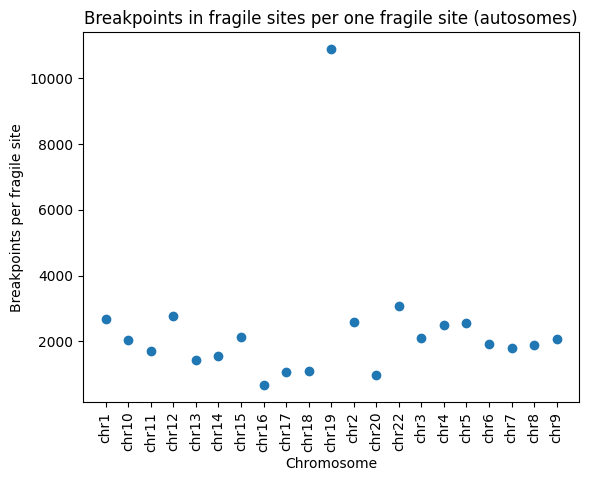

,BreaksInFragile,FragileSites,BreaksPerFragileSite
Chromosome,,,
chr1,29409,11,2673.545455
chr10,12197,6,2032.833333
chr11,15410,9,1712.222222
chr12,13907,5,2781.400000
chr13,7176,5,1435.200000
chr14,3135,2,1567.500000
chr15,2122,1,2122.000000
chr16,3363,5,672.600000
chr17,2144,2,1072.000000


In [9]:
# Breakpoints (inside fragile sites) per one fragile site, per chromosome.
n_fragile = {c: len(dict_fragile.get(c, [])) for c in chroms}
per_chr['FragileSites'] = pd.Series(n_fragile)
per_chr['BreaksPerFragileSite'] = per_chr['BreaksInFragile'] / per_chr['FragileSites']

# Autosomes with at least one fragile site (avoid divide-by-zero).
aut = cns.only_aut(per_chr.reset_index().rename(columns={'Chromosome': 'chrom'}))
aut = aut[aut['FragileSites'] > 0]

fig, ax = plt.subplots()
ax.scatter(range(len(aut)), aut['BreaksPerFragileSite'])
ax.set_xticks(range(len(aut)))
ax.set_xticklabels(aut['chrom'], rotation=90)
ax.set_xlabel('Chromosome')
ax.set_ylabel('Breakpoints per fragile site')
ax.set_title('Breakpoints in fragile sites per one fragile site (autosomes)')
plt.show()

per_chr[['BreaksInFragile', 'FragileSites', 'BreaksPerFragileSite']]

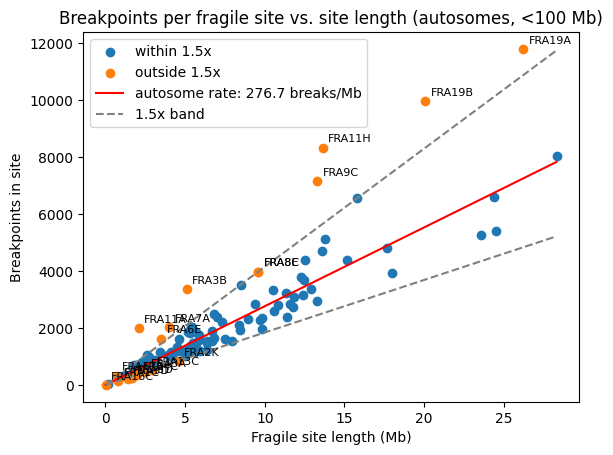

,chrom,name,SiteLen,Breaks,SiteLenMb
50,chr19,FRA19A,26227444,11802,26.227444
49,chr19,FRA19B,20050809,9972,20.050809
21,chr11,FRA11H,13643574,8339,13.643574
0,chr1,FRA1A,28316511,8052,28.316511
110,chr9,FRA9C,13300000,7166,13.300000
...,...,...,...,...,...
80,chr5,FRA5D,1656116,247,1.656116
111,chr9,FRA9D,1400000,200,1.400000
3,chr1,FRA1C,800000,138,0.800000
15,chr10,FRA10E,149597,43,0.149597


In [10]:
# Number of breakpoints in each individual fragile site vs. the site's length.
import bisect

# Pre-sort interior breakpoints per chromosome for fast range counting.
sorted_breaks = {c: sorted(interior_breaks[c]) for c in chroms}

site_rows = []
for c in chroms:
    if c not in assembly.aut_names:
        continue
    bps = sorted_breaks[c]
    for (start, end, name) in dict_fragile.get(c, []):
        n = bisect.bisect_left(bps, end) - bisect.bisect_left(bps, start)
        site_rows.append({'chrom': c, 'name': name,
                          'SiteLen': end - start, 'Breaks': n})

sites = pd.DataFrame(site_rows)
sites['SiteLenMb'] = sites['SiteLen'] / 1e6
sites = sites[sites['SiteLenMb'] <= 100]  # drop the one outsized site (FRA2S, ~111 Mb)

# Expected line from the overall autosome-wide breakpoint rate (uniform-density null),
# rather than fitting the fragile-site points directly.
aut_chroms = [c for c in chroms if c in assembly.aut_names]
aut_total_breaks = sum(len(interior_breaks[c]) for c in aut_chroms)
aut_len = sum(assembly.chr_lens[c] for c in aut_chroms)
slope = aut_total_breaks / aut_len * 1e6  # breaks per Mb across all autosomes
intercept = 0.0

# 1.5x band around the expected line (upper = 1.5*expected, lower = expected/1.5).
fit_vals = slope * sites['SiteLenMb'] + intercept
outside = (sites['Breaks'] > 1.5 * fit_vals) | (sites['Breaks'] < fit_vals / 1.5)

fig, ax = plt.subplots()
ax.scatter(sites.loc[~outside, 'SiteLenMb'], sites.loc[~outside, 'Breaks'],
           color='tab:blue', label='within 1.5x')
ax.scatter(sites.loc[outside, 'SiteLenMb'], sites.loc[outside, 'Breaks'],
           color='tab:orange', label='outside 1.5x')

# Expected line (autosome rate) and 1.5x boundaries.
xs = np.array([sites['SiteLenMb'].min(), sites['SiteLenMb'].max()])
fit_line = slope * xs + intercept
ax.plot(xs, fit_line, color='red', label=f'autosome rate: {slope:.1f} breaks/Mb')
ax.plot(xs, 1.5 * fit_line, color='gray', linestyle='--', label='1.5x band')
ax.plot(xs, fit_line / 1.5, color='gray', linestyle='--')

# Label the out-of-band sites.
for _, r in sites.loc[outside].iterrows():
    ax.annotate(r['name'], (r['SiteLenMb'], r['Breaks']),
                textcoords='offset points', xytext=(4, 4), fontsize=8)

ax.set_xlabel('Fragile site length (Mb)')
ax.set_ylabel('Breakpoints in site')
ax.set_title('Breakpoints per fragile site vs. site length (autosomes, <100 Mb)')
ax.legend()
plt.show()

sites.sort_values('Breaks', ascending=False)

n = 113 fragile sites
sample skewness = 2.609
skew-normal fit: a = 6.872 (right-skewed), loc = 0.1767, scale = 0.1618
KS vs skew-normal: D = 0.1374, p = 2.527e-02
KS vs normal     : D = 0.1712, p = 2.288e-03


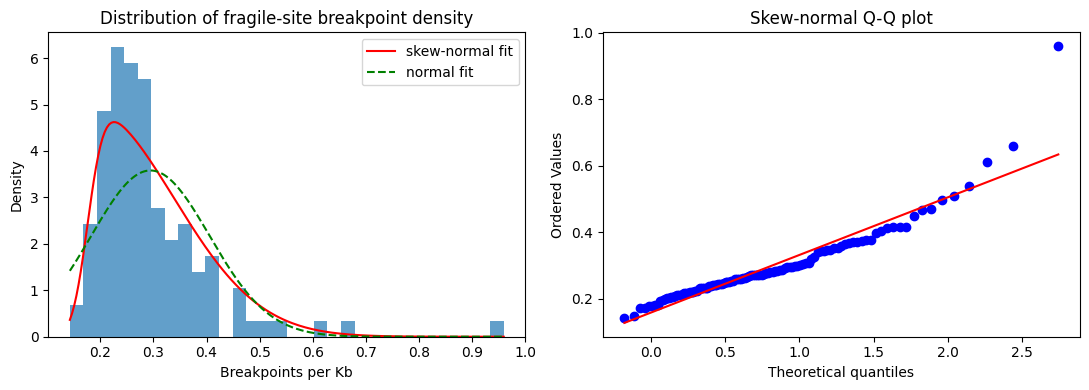

In [15]:
# Distribution of the per-Kb breakpoint density of fragile sites: skew-normal fit.
from scipy import stats

sites['BreaksPerKb'] = sites['Breaks'] / sites['SiteLen'] * 1000
x = sites['BreaksPerKb'].dropna()

mu, sd = x.mean(), x.std(ddof=1)

# Fit a skew-normal (shape a < 0 => left-skewed, a > 0 => right-skewed).
a, loc, scale = stats.skewnorm.fit(x)
# Goodness-of-fit vs. the fitted skew-normal (and the plain normal for reference).
ks_skew = stats.kstest(x, 'skewnorm', args=(a, loc, scale))
ks_norm = stats.kstest(x, 'norm', args=(mu, sd))

print(f"n = {len(x)} fragile sites")
print(f"sample skewness = {stats.skew(x):.3f}")
print(f"skew-normal fit: a = {a:.3f} ({'left' if a < 0 else 'right'}-skewed), "
      f"loc = {loc:.4f}, scale = {scale:.4f}")
print(f"KS vs skew-normal: D = {ks_skew.statistic:.4f}, p = {ks_skew.pvalue:.3e}")
print(f"KS vs normal     : D = {ks_norm.statistic:.4f}, p = {ks_norm.pvalue:.3e}")

# Visual check: histogram with skew-normal (and normal) overlay, and a skew-normal Q-Q plot.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.hist(x, bins=32, density=True, color='tab:blue', alpha=0.7)
grid = np.linspace(x.min(), x.max(), 200)
ax1.plot(grid, stats.skewnorm.pdf(grid, a, loc, scale), 'r-', label='skew-normal fit')
ax1.plot(grid, stats.norm.pdf(grid, mu, sd), 'g--', label='normal fit')
ax1.set_xlabel('Breakpoints per Kb')
ax1.set_ylabel('Density')
ax1.set_title('Distribution of fragile-site breakpoint density')
ax1.legend()

stats.probplot(x, dist=stats.skewnorm, sparams=(a,), plot=ax2)
ax2.set_title('Skew-normal Q-Q plot')
plt.tight_layout()
plt.show()

In [12]:
# Z-score of breaks-per-Kb, per fragile site (>100 Mb site already excluded from `sites`).
mu = sites['BreaksPerKb'].mean()
sd = sites['BreaksPerKb'].std(ddof=1)
sites['BreaksPerKbZ'] = (sites['BreaksPerKb'] - mu) / sd

print(f"n = {len(sites)} fragile sites")
print(f"BreaksPerKb: mean = {mu:.4f}, std = {sd:.4f}")
sites[['chrom', 'name', 'SiteLenMb', 'Breaks', 'BreaksPerKb', 'BreaksPerKbZ']] \
    .sort_values('BreaksPerKbZ', ascending=False)

n = 113 fragile sites
BreaksPerKb: mean = 0.2944, std = 0.1114


,chrom,name,SiteLenMb,Breaks,BreaksPerKb,BreaksPerKbZ
22,chr11,FRA11A,2.078638,1994,0.959282,5.967244
69,chr3,FRA3B,5.099949,3357,0.658242,3.265311
21,chr11,FRA11H,13.643574,8339,0.611203,2.843126
110,chr9,FRA9C,13.300000,7166,0.538797,2.193255
96,chr7,FRA7A,3.986013,2024,0.507776,1.914827
...,...,...,...,...,...,...
76,chr4,FRA4C,1.999999,353,0.176500,-1.058477
3,chr1,FRA1C,0.800000,138,0.172500,-1.094380
41,chr16,FRA16C,0.017463,3,0.171792,-1.100736
80,chr5,FRA5D,1.656116,247,0.149144,-1.304006


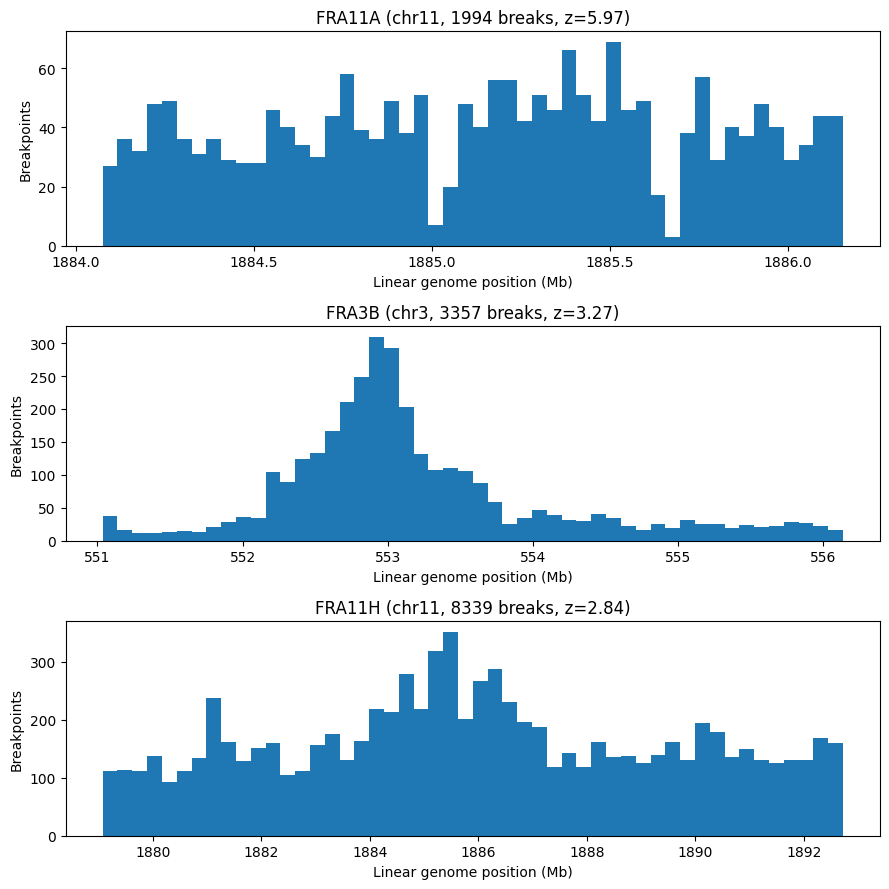

In [13]:
# Histogram of breakpoints on the linear genome for the top-3 fragile sites (by BreaksPerKb z-score).
top3 = sites.sort_values('BreaksPerKbZ', ascending=False).head(3)

# name -> (chrom, start, end) lookup for the fragile sites.
site_coords = {name: (c, s, e)
               for c in chroms for (s, e, name) in dict_fragile.get(c, [])}

fig, axes = plt.subplots(3, 1, figsize=(9, 9))
for ax, (_, r) in zip(axes, top3.iterrows()):
    c, s, e = site_coords[r['name']]
    lo = bisect.bisect_left(sorted_breaks[c], s)
    hi = bisect.bisect_left(sorted_breaks[c], e)
    # Linear-genome coordinate = chromosome offset + within-chromosome position.
    pos = (assembly.chr_starts[c] + np.array(sorted_breaks[c][lo:hi])) / 1e6
    ax.hist(pos, bins=50, color='tab:blue')
    ax.set_title(f"{r['name']} ({c}, {r['Breaks']} breaks, z={r['BreaksPerKbZ']:.2f})")
    ax.set_xlabel('Linear genome position (Mb)')
    ax.set_ylabel('Breakpoints')

plt.tight_layout()
plt.show()

In [14]:
# Overall, autosomes only (drop chrX / chrY).
aut_chroms = [c for c in chroms if c in assembly.aut_names]

aut_fragile_bp = sum(end - start for c in aut_chroms for (start, end, _) in dict_fragile.get(c, []))
aut_genome_bp = sum(assembly.chr_lens[c] for c in aut_chroms)
aut_prop_genome_fragile = aut_fragile_bp / aut_genome_bp

aut_total_breaks = sum(len(interior_breaks[c]) for c in aut_chroms)
aut_breaks_in_fragile = sum(in_fragile(c, p) for c in aut_chroms for p in interior_breaks[c])
aut_prop_breaks_fragile = aut_breaks_in_fragile / aut_total_breaks

aut_enrichment = aut_prop_breaks_fragile / aut_prop_genome_fragile

print("Enrichment - Autosomes only (chr1-22):")
print(f"Genome covered by fragile sites : {aut_fragile_bp:,} / {aut_genome_bp:,} bp = {aut_prop_genome_fragile:.4%}")
print(f"Breakpoints in fragile sites    : {aut_breaks_in_fragile:,} / {aut_total_breaks:,} = {aut_prop_breaks_fragile:.4%}")
print(f"\nEnrichment (breakpoints vs. genome share): {aut_enrichment:.2f}x")

Enrichment - Autosomes only (chr1-22):
Genome covered by fragile sites : 925,652,936 / 2,881,033,286 bp = 32.1292%
Breakpoints in fragile sites    : 252,235 / 797,125 = 31.6431%

Enrichment (breakpoints vs. genome share): 0.98x
